# MISO Regional Queue, Project Risk, Priority, and Queue-Cap Prototype

## 1. Executive summary and connection to the challenge

This executable prototype connects synthetic large-load growth with the MISO generator interconnection queue. It demonstrates the team's proposal: a controlled transition, smaller state-level demonstration queues with cross-regional review, leakage-safe historical withdrawal risk, a separate anti-starvation priority score, and periodic regional intake windows.

The model is a transparent analytical prototype, not an engineering interconnection study, tariff proposal, legal conclusion, or replacement for MISO stakeholder and regulatory processes. State is used as the demonstration queue key; Study Group, Transmission Owner, county, and POI remain coordination dimensions because state borders do not define electrical boundaries.

## 2. Team proposal and policy flow

**Phase 1 (illustrative six-month transition):** pause ordinary intake, rescore the backlog, form regional cohorts, study shared-upgrade exposure, and sequence eligible projects using readiness plus queue age.

**Phase 2:** use periodic regional application windows, equal initial deposits, completeness-gated first-complete/first-served admission, regional caps based on accredited capacity and MISO footprint share, staged milestones, and cross-region joint-study review. This is called a regional intake market only in the team's policy sense; it is not a highest-price auction.

Risk and priority remain separate: higher modeled withdrawal risk lowers readiness, while time in queue prevents viable older projects from permanent displacement.

In [1]:
from pathlib import Path
import warnings, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix, roc_curve
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.calibration import calibration_curve
from scipy.stats import wilcoxon

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', context='notebook')
DATA_AS_OF_DATE = pd.Timestamp('2026-09-11', tz='UTC')
OUTCOME_MONTHS = 36
OPEN_STATUSES = {'ACTIVE', 'PENDING REVISION APPROVAL', 'PENDING TRANSFER'}
INCLUDE_LOCATION_FEATURES = False
BACKLOG_FREEZE_MONTHS = 6
QUEUE_CAP_PERCENT = 0.10
POSITION_CAP_BY_REGION = {}
EQUAL_INITIAL_DEPOSIT = 250000
MARKET_WINDOW_MONTHS = 6
MIN_APPLICATION_COMPLETENESS = 1.0
PRIORITY_WEIGHTS_CORE = {'readiness': 0.70, 'age': 0.30, 'need': 0.00}
PRIORITY_WEIGHTS_NEED = {'readiness': 0.50, 'age': 0.25, 'need': 0.25}
assert abs(sum(PRIORITY_WEIGHTS_CORE.values()) - 1) < 1e-9
assert abs(sum(PRIORITY_WEIGHTS_NEED.values()) - 1) < 1e-9
PROHIBITED_MODEL_FEATURES = {'Project #','Request Status','Withdrawn Date','Done Date','Post GIA Status','Negotiated In Service Date','Study Phase','Decision Point 1 ERIS MW','Decision Point 1 NRIS MW','Decision Point 2 ERIS MW','Decision Point 2 NRIS MW'}
OUTPUT_DIR = REPO_ROOT / 'outputs'; FIG_DIR = OUTPUT_DIR / 'figures'; TEMPLATE_DIR = REPO_ROOT / 'data/templates'
OUTPUT_DIR.mkdir(exist_ok=True); FIG_DIR.mkdir(exist_ok=True); TEMPLATE_DIR.mkdir(parents=True, exist_ok=True)
print('As of:', DATA_AS_OF_DATE.date(), '| Seed:', RANDOM_SEED)

As of: 2026-09-11 | Seed: 42


## 4. File discovery and source registry

The loader identifies files by schema as well as filename. External operational inputs are optional and are never silently fabricated. Missing inputs produce a registry record and, where useful, a header-only template.

In [2]:
REQUIRED_QUEUE = {'Project #','Request Status','Queue Date','State','Study Group','Transmission Owner','POI Name','Summer MW','Winter MW','Fuel','Generating Facility','Service Type'}
REQUIRED_LOAD = {'STATE','YEAR','INCREMENTAL_LOAD_MW'}
def discover_file(required, suffixes):
    candidates = sorted(REPO_ROOT.rglob('*'))
    for p in candidates:
        if p.is_file() and p.suffix.lower() in suffixes and not any(part.startswith('.') for part in p.parts):
            try:
                if p.suffix.lower() == '.csv': cols = set(pd.read_csv(p, nrows=0).columns)
                else: cols = set(pd.read_excel(p, sheet_name=0, nrows=0).columns)
                if required <= cols: return p
            except Exception: pass
    return None
queue_path = discover_file(REQUIRED_QUEUE, {'.csv', '.xlsx'})
load_path = discover_file(REQUIRED_LOAD, {'.xlsx', '.csv'})
assert queue_path is not None and load_path is not None, 'Required source discovery failed'
raw_queue = pd.read_csv(queue_path) if queue_path.suffix.lower() == '.csv' else pd.read_excel(queue_path)
raw_load = pd.read_excel(load_path, sheet_name='DATA') if load_path.suffix.lower() == '.xlsx' else pd.read_csv(load_path)
source_registry = pd.DataFrame([
 {'Dataset':'Generator interconnection queue','Required or Optional':'Required','Purpose':'Historical withdrawal and current open project analysis','Expected Fields':'; '.join(sorted(REQUIRED_QUEUE)),'Join Key':'Project #','Source Organization':'Supplied repository','Source URL':'','File Found':str(queue_path),'Data As Of':str(DATA_AS_OF_DATE.date()),'Limitation if Missing':''},
 {'Dataset':'Synthetic large-load forecast','Required or Optional':'Required','Purpose':'Regional need and queue pressure','Expected Fields':'STATE; YEAR; INCREMENTAL_LOAD_MW','Join Key':'State/Region_ID','Source Organization':'Supplied repository','Source URL':'','File Found':str(load_path),'Data As Of':str(DATA_AS_OF_DATE.date()),'Limitation if Missing':''},
])
display(source_registry)
print('Queue:', raw_queue.shape, '| Large load:', raw_load.shape)

,Dataset,Required or Optional,Purpose,Expected Fields,Join Key,Source Organization,Source URL,File Found,Data As Of,Limitation if Missing
0,Generator interconnection queue,Required,Historical withdrawal and current open project...,Fuel; Generating Facility; POI Name; Project #...,Project #,Supplied repository,,/workspaces/Team-7-Techpoint/GI Interactive Qu...,2026-09-11,
1,Synthetic large-load forecast,Required,Regional need and queue pressure,STATE; YEAR; INCREMENTAL_LOAD_MW,State/Region_ID,Supplied repository,,/workspaces/Team-7-Techpoint/LARGE_LOADS_BY_ST...,2026-09-11,


Queue: (3822, 24) | Large load: (52, 3)


## 5. Queue and large-load data validation

The supplied queue is expected to be approximately 3,822 rows and 24 columns; these are validation references rather than hardcoded assumptions. The load workbook's `DATA` sheet is the analytical source.

In [3]:
print('Queue status counts:'); display(raw_queue['Request Status'].value_counts(dropna=False).rename('Projects').to_frame())
print('Large-load totals:', raw_load['INCREMENTAL_LOAD_MW'].sum(), 'MW')
assert REQUIRED_QUEUE <= set(raw_queue.columns)
assert REQUIRED_LOAD <= set(raw_load.columns)
load_expected = {'INDIANA':11997, 'WISCONSIN':6855, 'LOUISIANA':5938}
load_checks = raw_load.groupby('STATE')['INCREMENTAL_LOAD_MW'].sum()
for state, expected in load_expected.items():
    actual = load_checks.get(state, np.nan)
    print(state, 'actual=', actual, 'reference=', expected, 'difference=', actual-expected if pd.notna(actual) else np.nan)

Queue status counts:


,Projects
Request Status,
Withdrawn,2143
Active,1030
Done,559
Pending Revision Approval,77
Pending Transfer,9
LEGACY: Done,4


Large-load totals: 50691 MW
INDIANA actual= 11997 reference= 11997 difference= 0
WISCONSIN actual= 6855 reference= 6855 difference= 0
LOUISIANA actual= 5938 reference= 5938 difference= 0


## 6. Data cleaning and data-quality findings

Raw frames remain unchanged. Cleaning standardizes dates, text, state codes, owner aliases, MW fields, and derived age/lead-time measures. The date and MW checks are displayed so judges can see where the prototype depends on source quality.

In [4]:
def clean_text(series):
    return series.astype('string').str.strip().str.replace(r'\s+', ' ', regex=True).str.replace(r'[.;]+$', '', regex=True).str.upper()
def standardize_state(series):
    mapping = {'ALABAMA':'AL','ARKANSAS':'AR','ILLINOIS':'IL','INDIANA':'IN','IOWA':'IA','KENTUCKY':'KY','LOUISIANA':'LA','MICHIGAN':'MI','MINNESOTA':'MN','MISSISSIPPI':'MS','MISSOURI':'MO','MONTANA':'MT','NORTH DAKOTA':'ND','SOUTH DAKOTA':'SD','TEXAS':'TX','WISCONSIN':'WI'}
    s = clean_text(series); return s.replace(mapping)
def canonicalize_owner(series):
    s = clean_text(series)
    aliases = {'NORTHERN STATES POWER COMPANY':'XEL ENERGY','NORTHERN STATES POWER CO':'XEL ENERGY','AMERICAN TRANSMISSION CO LLC':'AMERICAN TRANSMISSION COMPANY'}
    return s.replace(aliases)
def parse_dates(frame, columns):
    for col in columns:
        if col in frame: frame[col] = pd.to_datetime(frame[col], errors='coerce', utc=True)
    return frame

def clean_queue(frame):
    q = frame.copy()
    date_cols = ['Queue Date','Withdrawn Date','Done Date','Appl In Service Date','Negotiated In Service Date']
    q = parse_dates(q, date_cols)
    for c in ['Request Status','County','Study Cycle','Study Group','Study Phase','Service Type','POI Name','Fuel','Generating Facility','Post GIA Status']:
        q[c] = clean_text(q[c])
    q['State'] = standardize_state(q['State']); q['Transmission Owner'] = canonicalize_owner(q['Transmission Owner'])
    for c in ['Summer MW','Winter MW','Decision Point 1 ERIS MW','Decision Point 1 NRIS MW','Decision Point 2 ERIS MW','Decision Point 2 NRIS MW']:
        q[c] = pd.to_numeric(q[c], errors='coerce')
    q['Project_MW'] = q[['Summer MW','Winter MW']].max(axis=1)
    q['Log_Project_MW'] = np.log1p(q['Project_MW'].clip(lower=0))
    q['Seasonal_MW_Difference'] = q['Summer MW'] - q['Winter MW']
    lead = (q['Appl In Service Date'] - q['Queue Date']).dt.days / 30.4375
    q['Requested_Lead_Months'] = lead.where(lead.between(0, 240))
    q['Queue_Age_Months'] = ((DATA_AS_OF_DATE - q['Queue Date']).dt.days / 30.4375).clip(lower=0)
    q['Region_ID'] = q['State'].fillna('UNKNOWN'); q['Study_Region'] = q['Study Group']; q['Transmission_Area'] = q['Transmission Owner']
    q['Duplicate_Project_ID'] = q['Project #'].duplicated(keep=False)
    return q
queue = clean_queue(raw_queue)
quality = pd.DataFrame({'Field': queue.columns, 'Missing_Count':[queue[c].isna().sum() for c in queue.columns], 'Missing_Pct':[queue[c].isna().mean() for c in queue.columns]})
invalid_dates = pd.Series({'withdrawal_before_queue': ((queue['Withdrawn Date'] < queue['Queue Date'])).sum(), 'done_before_queue': ((queue['Done Date'] < queue['Queue Date'])).sum(), 'negative_mw': (queue['Project_MW'] < 0).sum(), 'duplicate_project_ids': queue['Project #'].duplicated().sum()})
display(invalid_dates.to_frame('Count')); display(quality.sort_values('Missing_Count', ascending=False).head(15))
loads = raw_load.copy(); loads['STATE'] = standardize_state(loads['STATE']); loads['YEAR'] = pd.to_numeric(loads['YEAR'], errors='coerce').astype('Int64'); loads['INCREMENTAL_LOAD_MW'] = pd.to_numeric(loads['INCREMENTAL_LOAD_MW'], errors='coerce')
loads = loads.dropna(subset=['STATE','YEAR','INCREMENTAL_LOAD_MW'])
loads['Cumulative_Incremental_Load_MW'] = loads.sort_values('YEAR').groupby('STATE')['INCREMENTAL_LOAD_MW'].cumsum()

,Count
withdrawal_before_queue,0
done_before_queue,1
negative_mw,0
duplicate_project_ids,1


,Field,Missing_Count,Missing_Pct
4,Done Date,3553,0.929618
19,Negotiated In Service Date,3215,0.841183
3,Withdrawn Date,1697,0.444008
18,Post GIA Status,1327,0.347200
11,Study Phase,423,0.110675
17,Generating Facility,269,0.070382
16,Fuel,268,0.070120
30,Study_Region,243,0.063579
10,Study Group,243,0.063579
9,Study Cycle,237,0.062009


## 7. Descriptive queue and withdrawal analysis

,Projects
Request Status,
ACTIVE,1030
DONE,559
LEGACY: DONE,4
PENDING REVISION APPROVAL,77
PENDING TRANSFER,9
WITHDRAWN,2143


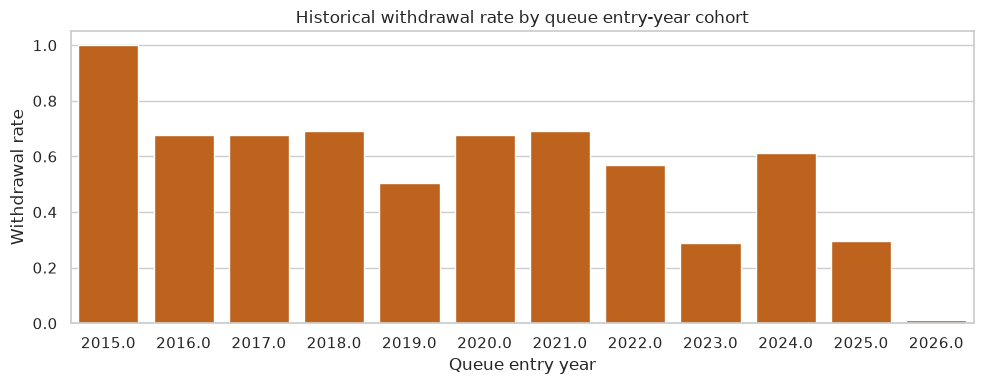

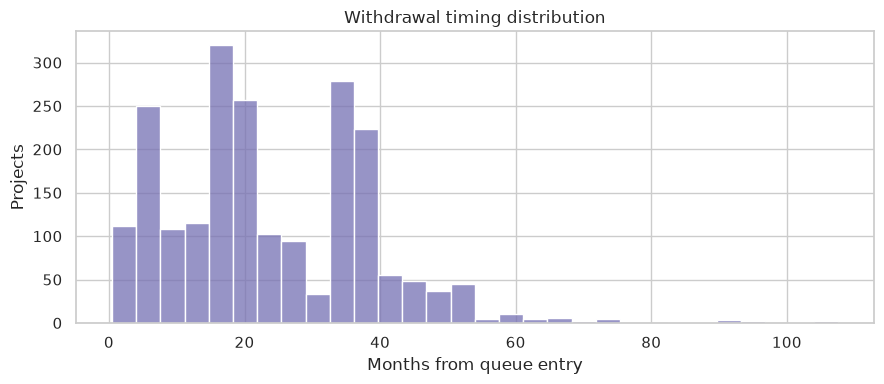

In [5]:
queue['Entry_Year'] = queue['Queue Date'].dt.year
outcome_counts = queue.groupby('Request Status').size().rename('Projects').to_frame()
display(outcome_counts)
cohort = queue.groupby('Entry_Year').agg(Projects=('Project #','size'), Queue_MW=('Project_MW','sum'), Withdrawn=('Request Status',lambda s:(s=='WITHDRAWN').sum())).reset_index()
cohort['Withdrawal_Rate'] = cohort['Withdrawn']/cohort['Projects']
fig, ax = plt.subplots(figsize=(10,4)); sns.barplot(data=cohort, x='Entry_Year', y='Withdrawal_Rate', color='#d95f02', ax=ax); ax.set(title='Historical withdrawal rate by queue entry-year cohort', ylabel='Withdrawal rate', xlabel='Queue entry year'); fig.tight_layout(); fig.savefig(FIG_DIR/'queue_outcomes_by_entry_year.png', dpi=160); plt.show()
withdrawn = queue[queue['Request Status'].eq('WITHDRAWN')].copy(); withdrawn['Withdrawal_Months'] = (withdrawn['Withdrawn Date']-withdrawn['Queue Date']).dt.days/30.4375
fig, ax = plt.subplots(figsize=(9,4)); sns.histplot(withdrawn['Withdrawal_Months'].dropna(), bins=30, color='#7570b3', ax=ax); ax.set(title='Withdrawal timing distribution', xlabel='Months from queue entry', ylabel='Projects'); fig.tight_layout(); fig.savefig(FIG_DIR/'withdrawal_timing_distribution.png', dpi=160); plt.show()

## 8. Large-load growth analysis

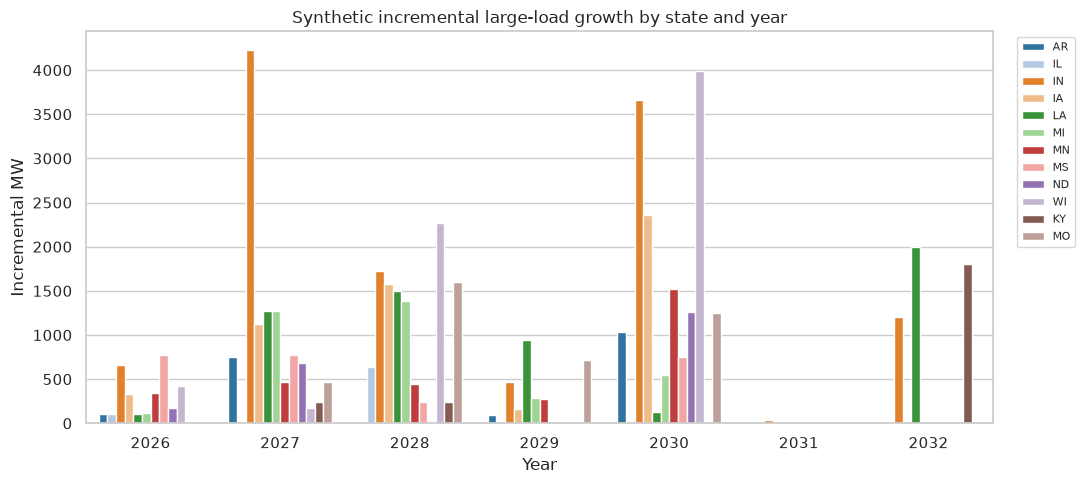

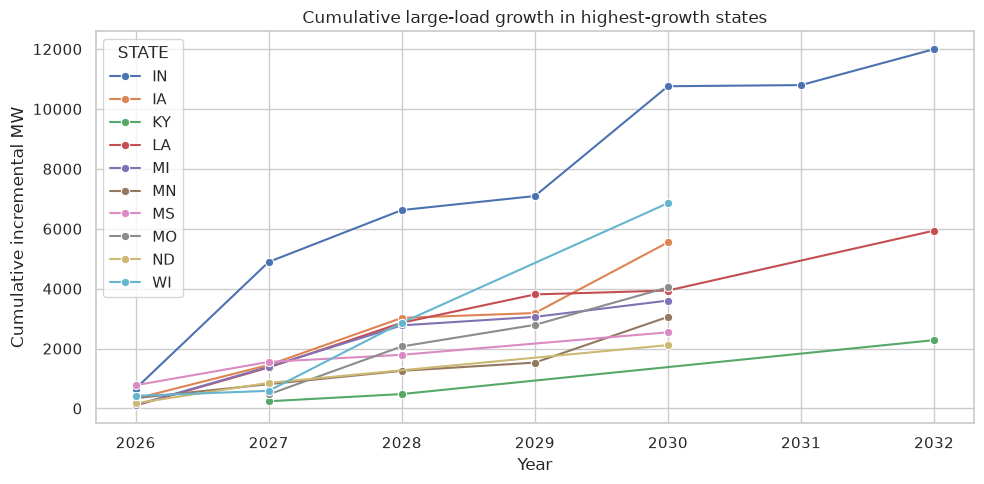

Top growth states:


,STATE,Total_Load_Growth_MW,Near_Term_Load_Growth_MW
3,IN,11997,10759
11,WI,6855,6855
5,LA,5938,3938
1,IA,5546,5546
8,MO,4042,4042
6,MI,3603,3603
7,MN,3058,3058
9,MS,2543,2543
4,KY,2282,482
10,ND,2116,2116


In [6]:
load_state = loads.groupby('STATE').agg(Total_Load_Growth_MW=('INCREMENTAL_LOAD_MW','sum'), Near_Term_Load_Growth_MW=('INCREMENTAL_LOAD_MW',lambda s: s[loads.loc[s.index,'YEAR']<=2030].sum())).reset_index()
load_year = loads.groupby('YEAR', as_index=False)['INCREMENTAL_LOAD_MW'].sum()
fig, ax = plt.subplots(figsize=(11,5)); sns.barplot(data=loads, x='YEAR', y='INCREMENTAL_LOAD_MW', hue='STATE', ax=ax, palette='tab20'); ax.set(title='Synthetic incremental large-load growth by state and year', ylabel='Incremental MW', xlabel='Year'); ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', ncol=1, fontsize=8); fig.tight_layout(); fig.savefig(FIG_DIR/'incremental_large_load_by_state_year.png', dpi=160); plt.show()
top_states = load_state.nlargest(10, 'Total_Load_Growth_MW')['STATE']
fig, ax = plt.subplots(figsize=(10,5)); sns.lineplot(data=loads[loads['STATE'].isin(top_states)], x='YEAR', y='Cumulative_Incremental_Load_MW', hue='STATE', marker='o', ax=ax); ax.set(title='Cumulative large-load growth in highest-growth states', ylabel='Cumulative incremental MW', xlabel='Year'); fig.tight_layout(); fig.savefig(FIG_DIR/'cumulative_load_growth_by_state.png', dpi=160); plt.show()
print('Top growth states:'); display(load_state.sort_values('Total_Load_Growth_MW', ascending=False).head(10))

## 9. Regional queue construction

In [7]:
open_queue = queue[queue['Request Status'].isin(OPEN_STATUSES)].copy()
regional_queue = queue.groupby('Region_ID').agg(Total_Queue_Projects=('Project #','size'), Open_Projects=('Request Status',lambda s:s.isin(OPEN_STATUSES).sum()), Open_Queue_MW=('Project_MW',lambda s: queue.loc[s.index].loc[queue.loc[s.index,'Request Status'].isin(OPEN_STATUSES),'Project_MW'].sum()), Median_Queue_Age_Months=('Queue_Age_Months','median'), P90_Queue_Age_Months=('Queue_Age_Months',lambda s:s.quantile(.9)), Withdrawn_Projects=('Request Status',lambda s:(s=='WITHDRAWN').sum()), Done_Projects=('Request Status',lambda s:(s=='DONE').sum())).reset_index()
regional_queue['Historical_Withdrawal_Rate'] = regional_queue['Withdrawn_Projects'] / regional_queue['Total_Queue_Projects']
regional_queue = regional_queue.merge(load_state.rename(columns={'STATE':'Region_ID'}), on='Region_ID', how='outer')
regional_queue = regional_queue.merge(loads[loads['YEAR'].isin([2030,2032])].groupby('STATE')['INCREMENTAL_LOAD_MW'].sum().rename('Load_Growth_2030_2032_MW'), left_on='Region_ID', right_index=True, how='outer')
regional_queue = regional_queue.drop(columns=['STATE'], errors='ignore')
display(regional_queue.sort_values('Open_Queue_MW', ascending=False).head(15))

,Region_ID,Total_Queue_Projects,Open_Projects,Open_Queue_MW,Median_Queue_Age_Months,P90_Queue_Age_Months,Withdrawn_Projects,Done_Projects,Historical_Withdrawal_Rate,Total_Load_Growth_MW,Near_Term_Load_Growth_MW,Load_Growth_2030_2032_MW
7,MI,530,210,43123.09,47.868583,101.979466,244,75,0.460377,3603.0,3603.0,545.0
3,IL,494,208,39267.11,47.835729,101.979466,218,68,0.441296,738.0,738.0,NaN
15,UNKNOWN,154,89,31094.93,11.104723,55.103080,25,39,0.162338,NaN,NaN,NaN
4,IN,468,98,21091.50,51.515400,88.410678,298,72,0.636752,11997.0,10759.0,4866.0
1,AR,406,80,19597.10,47.835729,88.410678,270,55,0.665025,1973.0,1973.0,1030.0
8,MN,285,101,18701.90,47.868583,107.781520,158,26,0.554386,3058.0,3058.0,1526.0
2,IA,228,74,15029.54,48.164271,101.979466,116,38,0.508772,5546.0,5546.0,2359.0
16,WI,248,71,14590.46,58.743326,102.009035,115,62,0.463710,6855.0,6855.0,3992.0
6,LA,387,65,14439.51,47.868583,88.410678,267,54,0.689922,5938.0,3938.0,2130.0
9,MO,129,33,8608.43,53.190965,101.979466,77,19,0.596899,4042.0,4042.0,1250.0


## 10. External-data interfaces and generated templates

The supplied repository contains no defensible accredited-capacity table, MISO footprint fraction table, applicant-readiness history, or authoritative adjacency file. The notebook creates templates for the operational fields and uses a clearly labeled prototype adjacency map for screening only. Queue caps therefore remain `DATA REQUIRED` rather than pretending nameplate MW is accredited capacity.

In [8]:
external_specs = [
 ('Regional accredited capacity','Required','Queue cap using seasonal accredited capacity','Region_ID; Season; Accredited_Capacity_MW; Data_As_Of; Source_URL','Region_ID','MISO','https://www.misoenergy.org/markets-and-operations/resource-adequacy/','accredited_capacity_template.csv','Accredited capacity not supplied; cap unavailable.'),
 ('MISO footprint share','Required','Partial-footprint adjustment','State; County; MISO_Footprint_Fraction; Method; Data_As_Of; Source_URL','State/County','MISO/Census','https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer.html','miso_footprint_template.csv','Do not assume 1.0 for partial states.'),
 ('Applicant readiness and developer history','Required','Readiness and historical milestone features','Project #; Applicant_ID; Application_Complete_Flag; Site_Control_Flag; Permit_Status; Financing_Status; Offtake_or_PPA_Status; Deposit_Posted_Flag; Equipment_Procurement_Status; Material_Modification_Count; Milestones_Met_Rate; Prior_Projects_Count; Prior_Withdrawal_Rate; Readiness_As_Of_Date','Project #','Applicant/MISO','','project_readiness_template.csv','Not available; Transmission Owner is not a developer identifier.'),
 ('State or regional adjacency','Optional','Geographic coordination screening','State_A; State_B; Adjacent_Flag; Source_URL','State pair','Census/analyst review','https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer.html','state_adjacency_template.csv','Prototype geographic adjacency is not electrical interaction.'),
 ('Generator fleet and retirement context','Optional','System context and retirement sensitivity','State; Balancing_Authority; Nameplate_MW; Status; Retirement_Date','State','EIA','https://www.eia.gov/electricity/data/eia860m/','','Not supplied; excluded from readiness labels.'),
]
for _,_,_,fields,_,_,_,filename,_ in external_specs:
    if filename: (TEMPLATE_DIR/filename).write_text(','.join(fields.split('; '))+'\n')
external_registry = pd.DataFrame([{'Dataset':a,'Required or Optional':b,'Purpose':c,'Expected Fields':d,'Join Key':e,'Source Organization':f,'Source URL':g,'File Found':'No','Data As Of':'','Limitation if Missing':i} for a,b,c,d,e,f,g,h,i in external_specs])
external_registry.to_csv(OUTPUT_DIR/'external_data_registry.csv', index=False); display(external_registry)
# Reviewed state adjacency prototype for represented states; used only as a screening flag.
adj_pairs = [('AR','MO'),('AR','MS'),('AR','LA'),('AR','TX'),('IA','IL'),('IA','MN'),('IA','MO'),('IA','SD'),('IA','WI'),('IL','IN'),('IL','IA'),('IL','KY'),('IL','MO'),('IL','WI'),('IN','KY'),('IN','MI'),('IN','IL'),('IN','OH'),('IN','WI'),('LA','MS'),('LA','TX'),('MI','WI'),('MI','IN'),('MN','IA'),('MN','WI'),('MN','SD'),('MN','ND'),('MO','AR'),('MO','IA'),('MO','IL'),('MO','KY'),('MO','KS'),('MO','OK'),('MO','TN'),('MS','AR'),('MS','LA'),('MS','MO'),('MS','TN'),('MT','ND'),('MT','SD'),('ND','MN'),('ND','MT'),('ND','SD'),('SD','IA'),('SD','MN'),('SD','MT'),('SD','ND'),('TX','AR'),('TX','LA'),('WI','IA'),('WI','IL'),('WI','IN'),('WI','MI'),('WI','MN')]
adjacency = pd.DataFrame(sorted(set(tuple(sorted(p)) for p in adj_pairs)), columns=['State_A','State_B']); adjacency['Adjacent_Flag']=1; adjacency['Source_URL']='Prototype reviewed mapping; replace with authoritative geography'
adjacency.to_csv(TEMPLATE_DIR/'state_adjacency_prototype.csv', index=False)

,Dataset,Required or Optional,Purpose,Expected Fields,Join Key,Source Organization,Source URL,File Found,Data As Of,Limitation if Missing
0,Regional accredited capacity,Required,Queue cap using seasonal accredited capacity,Region_ID; Season; Accredited_Capacity_MW; Dat...,Region_ID,MISO,https://www.misoenergy.org/markets-and-operati...,No,,Accredited capacity not supplied; cap unavaila...
1,MISO footprint share,Required,Partial-footprint adjustment,State; County; MISO_Footprint_Fraction; Method...,State/County,MISO/Census,https://www.census.gov/geographies/reference-f...,No,,Do not assume 1.0 for partial states.
2,Applicant readiness and developer history,Required,Readiness and historical milestone features,Project #; Applicant_ID; Application_Complete_...,Project #,Applicant/MISO,,No,,Not available; Transmission Owner is not a dev...
3,State or regional adjacency,Optional,Geographic coordination screening,State_A; State_B; Adjacent_Flag; Source_URL,State pair,Census/analyst review,https://www.census.gov/geographies/reference-f...,No,,Prototype geographic adjacency is not electric...
4,Generator fleet and retirement context,Optional,System context and retirement sensitivity,State; Balancing_Authority; Nameplate_MW; Stat...,State,EIA,https://www.eia.gov/electricity/data/eia860m/,No,,Not supplied; excluded from readiness labels.


## 11. Modeling population, observation window, and target definition

The primary outcome is withdrawal within 36 months. A project is a valid negative only when its full 36-month observation window is available. Recent active projects are not mislabeled as successes. Withdrawn projects lacking a withdrawal date are excluded from the fixed-horizon population and counted below.

In [9]:
queue['Outcome_Elapsed_Months'] = ((queue['Withdrawn Date'].fillna(DATA_AS_OF_DATE) - queue['Queue Date']).dt.days / 30.4375)
queue['Complete_36M_Observation'] = ((DATA_AS_OF_DATE - queue['Queue Date']).dt.days / 30.4375 >= OUTCOME_MONTHS)
queue['Withdrawal_Within_36M'] = np.where(queue['Complete_36M_Observation'], ((queue['Request Status']=='WITHDRAWN') & queue['Withdrawn Date'].notna() & (queue['Outcome_Elapsed_Months']<=OUTCOME_MONTHS)).astype(int), np.nan)
model_pop = queue[queue['Complete_36M_Observation'] & queue['Withdrawal_Within_36M'].notna()].copy()
print('Modeled records:', len(model_pop), '| withdrawal rate:', model_pop['Withdrawal_Within_36M'].mean(), '| recent censored:', queue['Withdrawal_Within_36M'].isna().sum(), '| withdrawn missing date:', ((queue['Request Status']=='WITHDRAWN') & queue['Withdrawn Date'].isna()).sum())

Modeled records: 2544 | withdrawal rate: 0.43160377358490565 | recent censored: 1278 | withdrawn missing date: 22


## 12. Leakage-safe feature engineering

In [10]:
BASE_FEATURES = ['Log_Project_MW','Seasonal_MW_Difference','Requested_Lead_Months','Fuel','Generating Facility','Service Type','Study Group']
MODEL_FEATURES = BASE_FEATURES + (['State','Transmission Owner'] if INCLUDE_LOCATION_FEATURES else [])
assert not set(MODEL_FEATURES) & PROHIBITED_MODEL_FEATURES
X = model_pop[MODEL_FEATURES].copy(); y = model_pop['Withdrawal_Within_36M'].astype(int)
num_features = [c for c in MODEL_FEATURES if c not in ['Fuel','Generating Facility','Service Type','Study Group','State','Transmission Owner']]
cat_features = [c for c in MODEL_FEATURES if c not in num_features]
for feature in cat_features:
    X[feature] = X[feature].astype(object).where(X[feature].notna(), np.nan)
    model_pop[feature] = model_pop[feature].astype(object).where(model_pop[feature].notna(), np.nan)
preprocess = ColumnTransformer([('num', Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]), num_features), ('cat', Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features)], remainder='drop')
logistic = Pipeline([('preprocess', preprocess), ('model', LogisticRegression(max_iter=1200, C=0.5, random_state=RANDOM_SEED, class_weight='balanced'))])
hgb = Pipeline([('preprocess', preprocess), ('model', HistGradientBoostingClassifier(max_iter=120, learning_rate=0.05, max_leaf_nodes=12, l2_regularization=1.0, random_state=RANDOM_SEED))])
print('Features:', MODEL_FEATURES)

Features: ['Log_Project_MW', 'Seasonal_MW_Difference', 'Requested_Lead_Months', 'Fuel', 'Generating Facility', 'Service Type', 'Study Group']


## 13. Chronological model comparison

Training uses 2016–2020 queue-entry cohorts and the later 2021–2022 cohorts are the primary holdout. This is intentionally chronological rather than a random split. The selected model favors simplicity unless a challenger improves ROC-AUC by at least 0.02 while preserving Brier score and calibration.

,Model,Train_N,Test_N,Train_Base_Rate,Test_Base_Rate,ROC_AUC,Average_Precision,Brier_Score,Threshold_0.5_TN,Threshold_0.5_FP,Threshold_0.5_FN,Threshold_0.5_TP
0,Logistic regression,1090,1435,0.514679,0.370732,0.640816,0.458233,0.234129,574,329,213,319
1,Histogram gradient boosting,1090,1435,0.514679,0.370732,0.593238,0.433666,0.250552,547,356,268,264


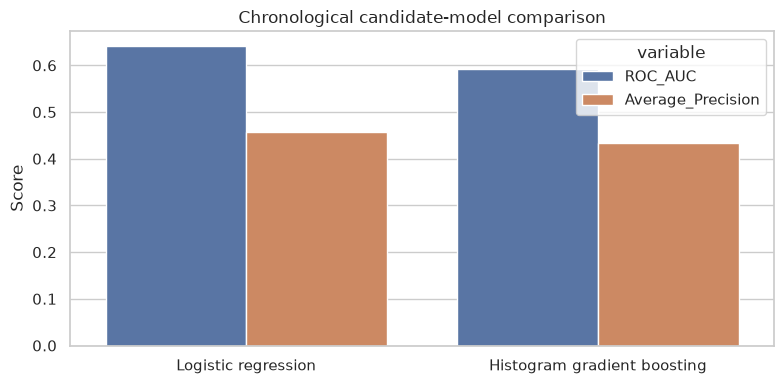

Selected: Logistic regression


In [11]:
dev = model_pop[model_pop['Entry_Year'].between(2016,2020)].copy(); test = model_pop[model_pop['Entry_Year'].between(2021,2022)].copy()
if len(test)==0: test = model_pop[model_pop['Entry_Year']>dev['Entry_Year'].max()].copy()
assert dev['Entry_Year'].max() < test['Entry_Year'].min()
models = {'Logistic regression': logistic, 'Histogram gradient boosting': hgb}
comparison=[]; fitted={}
for name, model in models.items():
    model.fit(dev[MODEL_FEATURES], dev['Withdrawal_Within_36M']); fitted[name]=model
    prob=model.predict_proba(test[MODEL_FEATURES])[:,1]; pred=(prob>=0.5).astype(int)
    comparison.append({'Model':name,'Train_N':len(dev),'Test_N':len(test),'Train_Base_Rate':dev['Withdrawal_Within_36M'].mean(),'Test_Base_Rate':test['Withdrawal_Within_36M'].mean(),'ROC_AUC':roc_auc_score(test['Withdrawal_Within_36M'],prob),'Average_Precision':average_precision_score(test['Withdrawal_Within_36M'],prob),'Brier_Score':brier_score_loss(test['Withdrawal_Within_36M'],prob),'Threshold_0.5_TN':confusion_matrix(test['Withdrawal_Within_36M'],pred).ravel()[0],'Threshold_0.5_FP':confusion_matrix(test['Withdrawal_Within_36M'],pred).ravel()[1],'Threshold_0.5_FN':confusion_matrix(test['Withdrawal_Within_36M'],pred).ravel()[2],'Threshold_0.5_TP':confusion_matrix(test['Withdrawal_Within_36M'],pred).ravel()[3]})
model_comparison=pd.DataFrame(comparison); display(model_comparison)
selected_name='Logistic regression'
best=model_comparison.sort_values('ROC_AUC',ascending=False).iloc[0]
if best['Model']!='Logistic regression' and best['ROC_AUC']-model_comparison.loc[model_comparison['Model'].eq('Logistic regression'),'ROC_AUC'].iloc[0]>=0.02 and best['Brier_Score']<=model_comparison.loc[model_comparison['Model'].eq('Logistic regression'),'Brier_Score'].iloc[0]: selected_name=best['Model']
selected_model=fitted[selected_name]
model_comparison['Selected']=model_comparison['Model'].eq(selected_name); model_comparison.to_csv(OUTPUT_DIR/'model_comparison.csv', index=False)
fig, ax=plt.subplots(figsize=(8,4)); sns.barplot(data=model_comparison.melt(id_vars='Model',value_vars=['ROC_AUC','Average_Precision']), x='Model', y='value', hue='variable', ax=ax); ax.set(title='Chronological candidate-model comparison', ylabel='Score', xlabel=''); fig.tight_layout(); fig.savefig(FIG_DIR/'model_comparison.png',dpi=160); plt.show(); print('Selected:',selected_name)

## 14. Probability calibration and risk-index construction

`Predicted_Withdrawal_36M` is a model probability estimate, not a claim that a 0–9 score is an absolute probability. The 0–9 index is relative: deciles learned from development out-of-fold predictions are applied unchanged to holdout and current projects. Duplicate thresholds can reduce the number of distinct levels.

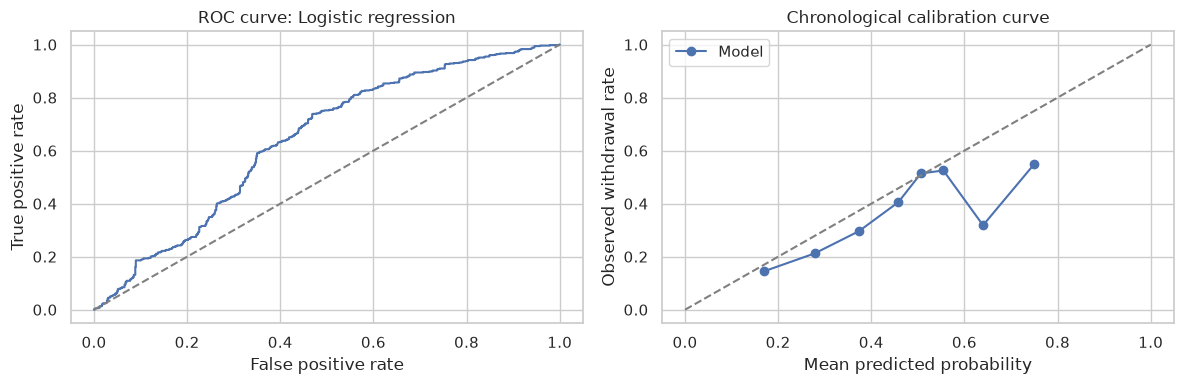

Relative-index thresholds: [0.26845794 0.31261634 0.38962966 0.46655343 0.51465612 0.56624167
 0.60819332 0.65710653 0.73171066] | distinct levels: 10


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
oof_dev = cross_val_predict(selected_model, dev[MODEL_FEATURES], dev['Withdrawal_Within_36M'], cv=cv, method='predict_proba')[:,1]
selected_model.fit(dev[MODEL_FEATURES], dev['Withdrawal_Within_36M'])
test_prob = selected_model.predict_proba(test[MODEL_FEATURES])[:,1]
thresholds=np.unique(np.quantile(oof_dev, np.linspace(0.1,0.9,9)))
def relative_index(prob, cuts): return np.searchsorted(cuts, prob, side='right').clip(0,9).astype(int)
# The model-development model is refit below after thresholds are learned.
test_index=relative_index(test_prob, thresholds)
fig, axes=plt.subplots(1,2,figsize=(12,4)); fpr,tpr,_=roc_curve(test['Withdrawal_Within_36M'],test_prob); axes[0].plot(fpr,tpr,label=f'AUC={roc_auc_score(test["Withdrawal_Within_36M"],test_prob):.3f}'); axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].set(title=f'ROC curve: {selected_name}',xlabel='False positive rate',ylabel='True positive rate'); frac,mean=calibration_curve(test['Withdrawal_Within_36M'],test_prob,n_bins=8,strategy='quantile'); axes[1].plot(mean,frac,'o-',label='Model'); axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].set(title='Chronological calibration curve',xlabel='Mean predicted probability',ylabel='Observed withdrawal rate'); axes[1].legend(); fig.tight_layout(); fig.savefig(FIG_DIR/'selected_model_roc_calibration.png',dpi=160); plt.show()
print('Relative-index thresholds:', thresholds, '| distinct levels:', len(thresholds)+1)

## 15. Historical score and tier validation

,Risk_Index_0_9,Operational_Risk_Tier,Project_Count,Observed_Withdrawal_Rate,Mean_Predicted_Probability
0,0,Lower risk,251,0.151394,0.193363
1,1,Lower risk,95,0.231579,0.289864
2,2,Lower risk,133,0.263158,0.352355
3,3,Moderate risk,176,0.375000,0.434496
4,4,Moderate risk,183,0.459016,0.492023
5,5,Moderate risk,183,0.551913,0.536175
6,6,Elevated risk,96,0.479167,0.585825
7,7,Elevated risk,77,0.324675,0.632393
8,8,Elevated risk,132,0.492424,0.698770
9,9,Elevated risk,109,0.458716,0.773227


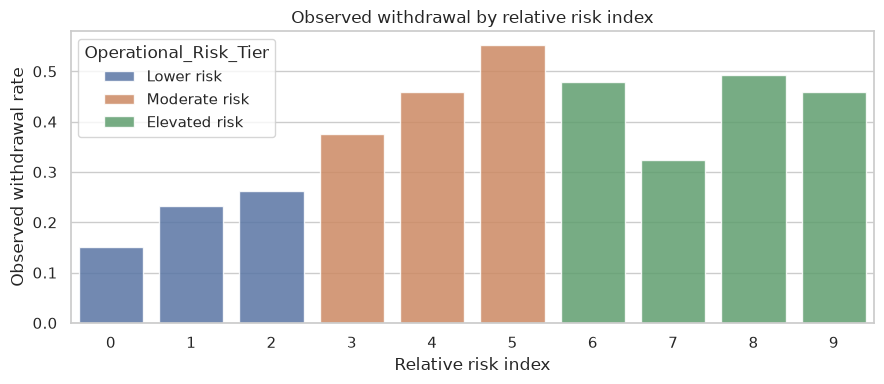

Calibration warning: absolute probability quality is limited when observed rates are non-monotonic or sparse; use the index for relative triage.


In [13]:
test_scored=test.copy(); test_scored['Risk_Index_0_9']=test_index; test_scored['Operational_Risk_Tier']=pd.cut(test_scored['Risk_Index_0_9'],[-1,2,5,9],labels=['Lower risk','Moderate risk','Elevated risk'])
risk_validation=test_scored.groupby(['Risk_Index_0_9','Operational_Risk_Tier'],observed=True).agg(Project_Count=('Project #','size'),Observed_Withdrawal_Rate=('Withdrawal_Within_36M','mean'),Mean_Predicted_Probability=('Project #',lambda s: test_prob[s.index[0]-test.index[0]] if False else np.nan)).reset_index()
# Rebuild aggregate probability by score without index arithmetic assumptions.
test_scored['Predicted_Withdrawal_36M']=test_prob
risk_validation=test_scored.groupby(['Risk_Index_0_9','Operational_Risk_Tier'],observed=True).agg(Project_Count=('Project #','size'),Observed_Withdrawal_Rate=('Withdrawal_Within_36M','mean'),Mean_Predicted_Probability=('Predicted_Withdrawal_36M','mean')).reset_index()
risk_validation.to_csv(OUTPUT_DIR/'risk_score_validation.csv',index=False); display(risk_validation)
fig, ax=plt.subplots(figsize=(9,4)); sns.barplot(data=risk_validation,x='Risk_Index_0_9',y='Observed_Withdrawal_Rate',hue='Operational_Risk_Tier',dodge=False,alpha=.85,ax=ax); ax.set(title='Observed withdrawal by relative risk index',ylabel='Observed withdrawal rate',xlabel='Relative risk index'); fig.tight_layout(); fig.savefig(FIG_DIR/'observed_vs_predicted_risk_by_score.png',dpi=160); plt.show()
print('Calibration warning: absolute probability quality is limited when observed rates are non-monotonic or sparse; use the index for relative triage.')

## 16. Current open-project risk scoring

Current open projects receive the selected model's probability and relative index. Reasons are association-based and intentionally avoid causal language. The absence of applicant identity, site control, permitting, financing, offtake, deposit, and dated milestone snapshots is a material production limitation.

In [14]:
current = open_queue.copy()
for feature in cat_features: current[feature] = current[feature].astype(object).where(current[feature].notna(), np.nan)
current['Predicted_Withdrawal_36M']=selected_model.predict_proba(current[MODEL_FEATURES])[:,1]; current['Risk_Index_0_9']=relative_index(current['Predicted_Withdrawal_36M'],thresholds); current['Operational_Risk_Tier']=pd.cut(current['Risk_Index_0_9'],[-1,2,5,9],labels=['Lower risk','Moderate risk','Elevated risk'])
# Plain-language reasons are historical associations, not causal explanations.
def reasons(row):
    vals=[]
    if row['Project_MW']>=queue['Project_MW'].median(): vals.append('Larger requested MW is associated with historical withdrawal risk')
    if pd.notna(row['Requested_Lead_Months']) and row['Requested_Lead_Months']>=queue['Requested_Lead_Months'].median(): vals.append('Longer requested lead time is associated with historical withdrawal risk')
    if row['Fuel'] in queue['Fuel'].value_counts().nlargest(3).index: vals.append(f"Fuel category ({row['Fuel']}) reflects a historical association")
    vals.append(f"Study Group ({row['Study Group']}) is a historical context feature")
    return vals[:3]
current[['Risk_Reason_1','Risk_Reason_2','Risk_Reason_3']]=current.apply(lambda r: pd.Series((reasons(r)+['']*3)[:3]),axis=1)
print('Current open projects by risk tier:'); display(current['Operational_Risk_Tier'].value_counts().rename('Projects').to_frame())

Current open projects by risk tier:


,Projects
Operational_Risk_Tier,
Lower risk,433
Moderate risk,415
Elevated risk,268


## 17. Regional need scoring

Need is system stress, not project readiness. The prototype uses cumulative large-load growth and open queue MW. A risk-adjusted queue measure discounts queue nameplate MW by predicted withdrawal probability; it is a scenario estimate, not accredited or deliverable capacity.

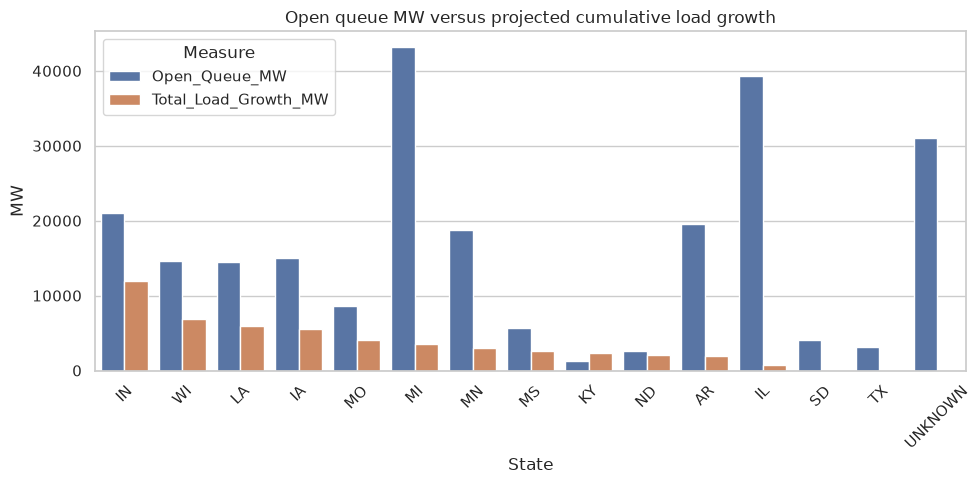

In [15]:
current_region = current.groupby('Region_ID').agg(Open_Queue_MW=('Project_MW','sum'), Risk_Adjusted_Queue_MW=('Predicted_Withdrawal_36M',lambda s: np.nan)).reset_index()
current['Risk_Adjusted_Queue_MW']=current['Project_MW']*(1-current['Predicted_Withdrawal_36M'])
current_region=current.groupby('Region_ID').agg(Open_Queue_MW=('Project_MW','sum'),Risk_Adjusted_Queue_MW=('Risk_Adjusted_Queue_MW','sum'),Open_Projects=('Project #','size')).reset_index()
need=current_region.merge(load_state.rename(columns={'STATE':'Region_ID'}),on='Region_ID',how='outer').fillna(0)
need=need.drop_duplicates('Region_ID', keep='first')
def percentile_0_9(s): return (s.rank(method='average',pct=True)*9).round().clip(0,9)
need['Regional_Need_Score_0_9']=percentile_0_9(need['Total_Load_Growth_MW'].fillna(0)+need['Open_Queue_MW'].fillna(0)/100)
regional_queue=regional_queue.drop(columns=['Regional_Need_Score_0_9'],errors='ignore').merge(need[['Region_ID','Regional_Need_Score_0_9','Risk_Adjusted_Queue_MW']],on='Region_ID',how='left')
fig, ax=plt.subplots(figsize=(10,5)); plot=need.sort_values('Total_Load_Growth_MW',ascending=False).head(15); plot=plot.melt(id_vars='Region_ID',value_vars=['Open_Queue_MW','Total_Load_Growth_MW'],var_name='Measure',value_name='MW'); sns.barplot(data=plot,x='Region_ID',y='MW',hue='Measure',ax=ax); ax.set(title='Open queue MW versus projected cumulative load growth',ylabel='MW',xlabel='State'); ax.tick_params(axis='x',rotation=45); fig.tight_layout(); fig.savefig(FIG_DIR/'open_queue_vs_load_growth.png',dpi=160); plt.show()

## 18. Eligibility and priority scoring

Eligibility gates study positions. Where readiness fields are absent, the demonstration labels open projects `ASSUMED ELIGIBLE FOR DEMONSTRATION`; this is not a production eligibility finding. Priority converts risk to readiness and then adds age, preserving the team's anti-starvation principle. A need-weighted sensitivity is shown separately.

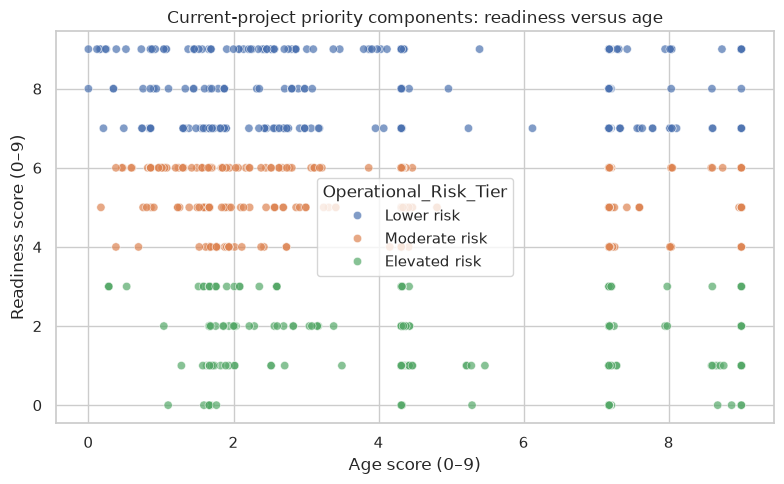

In [16]:
current['Eligibility_Status']='ASSUMED ELIGIBLE FOR DEMONSTRATION'
current['Readiness_Score_0_9']=(9-current['Risk_Index_0_9']).astype(int)
current['Age_Score_0_9']=(9*current['Queue_Age_Months'].fillna(0)/60).clip(0,9)
need_lookup=need.set_index('Region_ID')['Regional_Need_Score_0_9']
current['Regional_Need_Score_0_9']=current['Region_ID'].map(need_lookup).fillna(0)
def priority(row,w): return np.clip(w['readiness']*row['Readiness_Score_0_9']+w['age']*row['Age_Score_0_9']+w['need']*row['Regional_Need_Score_0_9'],0,9)
current['Priority_Score_0_9']=current.apply(lambda r: priority(r,PRIORITY_WEIGHTS_CORE),axis=1); current['Priority_Score_Need_Sensitivity_0_9']=current.apply(lambda r: priority(r,PRIORITY_WEIGHTS_NEED),axis=1)
current=current.sort_values(['Region_ID','Eligibility_Status','Priority_Score_0_9','Queue Date','Project #'],ascending=[True,True,False,True,True]); current['Regional_Rank']=current.groupby('Region_ID').cumcount()+1
fig, ax=plt.subplots(figsize=(8,5)); sns.scatterplot(data=current.sample(min(len(current),1000),random_state=RANDOM_SEED),x='Age_Score_0_9',y='Readiness_Score_0_9',hue='Operational_Risk_Tier',alpha=.7,ax=ax); ax.set(title='Current-project priority components: readiness versus age',xlabel='Age score (0–9)',ylabel='Readiness score (0–9)'); fig.tight_layout(); fig.savefig(FIG_DIR/'priority_readiness_age_matrix.png',dpi=160); plt.show()

## 19. Regional queue caps and market-window status

The cap formula is implemented, but the result is unavailable until actual accredited capacity and MISO footprint fractions are supplied. This is deliberate: nameplate queue MW is not substituted for accredited capacity. The market-window demonstration below is a policy simulation, not actual applicant data.

In [17]:
regional_queue['MISO_Footprint_Fraction']=np.nan; regional_queue['Accredited_Capacity_MW']=np.nan; regional_queue['Effective_Accredited_Capacity_MW']=np.nan; regional_queue['Queue_Cap_MW']=np.nan; regional_queue['Available_Queue_MW']=np.nan; regional_queue['Queue_Cap_Utilization']=np.nan; regional_queue['Available_Project_Positions']=np.nan; regional_queue['Market_Window_Status']='DATA REQUIRED'
def demonstrate_intake_window(applications, available_positions, deposit=EQUAL_INITIAL_DEPOSIT):
    a=applications.copy(); a['Eligible']=a['Application_Complete_Flag'].astype(bool) & a['Deposit'].eq(deposit); a=a.sort_values('Complete_Application_Timestamp'); a['Admission_Order']=np.arange(1,len(a)+1); a['Window_Result']=np.where(a['Eligible'] & (a['Admission_Order']<=available_positions),'ADMITTED','NEXT WINDOW / INELIGIBLE'); return a
example_apps=pd.DataFrame({'Project #':['DEMO-001','DEMO-002','DEMO-003','DEMO-004'],'Application_Complete_Flag':[1,1,1,0],'Deposit':[EQUAL_INITIAL_DEPOSIT]*4,'Complete_Application_Timestamp':pd.to_datetime(['2026-01-02','2026-01-03','2026-01-04','2026-01-01'])})
window_demo=demonstrate_intake_window(example_apps,available_positions=2); display(window_demo)
print('Cap status:', regional_queue['Market_Window_Status'].value_counts().to_dict())

,Project #,Application_Complete_Flag,Deposit,Complete_Application_Timestamp,Eligible,Admission_Order,Window_Result
3,DEMO-004,0,250000,2026-01-01,False,1,NEXT WINDOW / INELIGIBLE
0,DEMO-001,1,250000,2026-01-02,True,2,ADMITTED
1,DEMO-002,1,250000,2026-01-03,True,3,NEXT WINDOW / INELIGIBLE
2,DEMO-003,1,250000,2026-01-04,True,4,NEXT WINDOW / INELIGIBLE


Cap status: {'DATA REQUIRED': 17}


## 20. Neighboring-region/joint-study screening

This is a non-engineering screen. Projects are grouped efficiently by shared POI, Study Group, Transmission Owner, county, study cycle, and adjacent states. Only MISO network models and engineering studies can determine actual interaction or shared upgrades.

In [18]:
keys=['Study Group','Transmission Owner','POI Name','County','Study Cycle']
for c in keys: queue[c]=queue[c].fillna('UNKNOWN')
queue['Joint_Study_Screen']=False
for _, group in queue.groupby(keys, dropna=False):
    if len(group)>1: queue.loc[group.index,'Joint_Study_Screen']=True
# Cross-state adjacency indicator for projects sharing study group/owner/cycle.
state_groups=queue.groupby(['Study Group','Transmission Owner','Study Cycle'])['State'].agg(lambda x:set(x.dropna()))
related=[]
for idx,row in queue.iterrows():
    states=state_groups.get((row['Study Group'],row['Transmission Owner'],row['Study Cycle']),set())
    related.append(len(states)>1)
queue['Joint_Study_Screen']=queue['Joint_Study_Screen'] | np.asarray(related, dtype=bool)
joint=queue[queue['Joint_Study_Screen']].groupby(['Region_ID','Study Group']).agg(Project_Count=('Project #','size'),States=('State',lambda x:', '.join(sorted(str(v) for v in set(x.dropna()))))).reset_index()
joint.to_csv(OUTPUT_DIR/'joint_study_screen.csv',index=False); print('Screened project records:',queue['Joint_Study_Screen'].sum()); display(joint.head(15))
project_joint_flags=queue[['Project #','Joint_Study_Screen']].groupby('Project #',as_index=False)['Joint_Study_Screen'].any()
joint_lookup=project_joint_flags.set_index('Project #')['Joint_Study_Screen']
current['Joint_Study_Screen']=current['Project #'].map(joint_lookup).fillna(False)

Screened project records: 1965


,Region_ID,Study Group,Project_Count,States
0,AK,SOUTH,1,AK
1,AR,NO_GROUP,2,AR
2,AR,SOUTH,234,AR
3,AR,UNKNOWN,5,AR
4,IA,CENTRAL,1,IA
5,IA,UNKNOWN,13,IA
6,IA,WEST,166,IA
7,IL,CENTRAL,288,IL
8,IL,EAST (ATC),1,IL
9,IL,NO_GROUP,3,IL


## 21. Shared-upgrade withdrawal scenario

This illustrative scenario allocates a fixed upgrade cost proportional to participating MW. It is not MISO's tariff or actual cost-allocation method; its purpose is to show why staged deposits, milestones, withdrawal fees, and readiness consequences matter.

,Project #,Participating_MW,Withdrawal_Step,Allocated_Cost,Cost_Increase_Pct,Cascade_Risk_Flag,Baseline_Cost
0,SCENARIO-A,400,0,4.000000e+07,0.000000,False,40000000.0
1,SCENARIO-B,300,0,3.000000e+07,0.000000,False,30000000.0
2,SCENARIO-C,200,0,2.000000e+07,0.000000,False,20000000.0
3,SCENARIO-D,100,0,1.000000e+07,0.000000,False,10000000.0
4,SCENARIO-A,400,1,4.444444e+07,11.111111,False,40000000.0
5,SCENARIO-B,300,1,3.333333e+07,11.111111,False,30000000.0
6,SCENARIO-C,200,1,2.222222e+07,11.111111,False,20000000.0
7,SCENARIO-A,400,2,5.714286e+07,42.857143,True,40000000.0
8,SCENARIO-B,300,2,4.285714e+07,42.857143,True,30000000.0
9,SCENARIO-A,400,3,1.000000e+08,150.000000,True,40000000.0


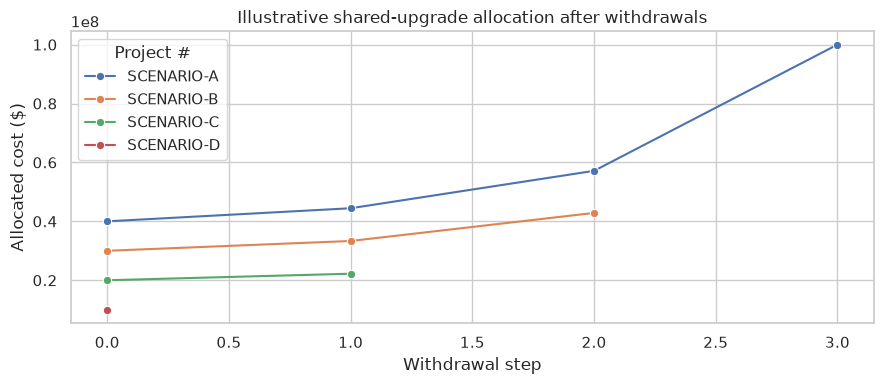

In [19]:
participants=pd.DataFrame({'Project #':['SCENARIO-A','SCENARIO-B','SCENARIO-C','SCENARIO-D'],'Participating_MW':[400,300,200,100]}); total_upgrade=100_000_000; rows=[]; remaining=participants.copy()
for step in range(0,len(participants)):
    total_mw=remaining['Participating_MW'].sum(); costs=remaining.assign(Withdrawal_Step=step,Allocated_Cost=total_upgrade*remaining['Participating_MW']/total_mw,Cost_Increase_Pct=np.nan,Cascade_Risk_Flag=False)
    if step>0:
        prior=rows[-1]['Allocated_Cost'] if False else None
    rows.extend(costs.to_dict('records'))
    if len(remaining)>1:
        leaving=remaining.iloc[-1]['Project #']; old=remaining.copy(); remaining=remaining.iloc[:-1].copy(); new_total=remaining['Participating_MW'].sum();
        for rec in rows[-len(remaining):]: rec['Cost_Increase_Pct']=np.nan
        # Record next round; comparison is calculated after aggregation.
scenario=pd.DataFrame(rows); baseline=scenario[scenario['Withdrawal_Step']==0][['Project #','Allocated_Cost']].rename(columns={'Allocated_Cost':'Baseline_Cost'}); scenario=scenario.merge(baseline,on='Project #',how='left'); scenario['Cost_Increase_Pct']=(scenario['Allocated_Cost']/scenario['Baseline_Cost']-1)*100; scenario['Cascade_Risk_Flag']=scenario['Cost_Increase_Pct']>=25
scenario.to_csv(OUTPUT_DIR/'shared_upgrade_withdrawal_scenario.csv',index=False); display(scenario)
fig,ax=plt.subplots(figsize=(9,4)); sns.lineplot(data=scenario,x='Withdrawal_Step',y='Allocated_Cost',hue='Project #',marker='o',ax=ax); ax.set(title='Illustrative shared-upgrade allocation after withdrawals',ylabel='Allocated cost ($)',xlabel='Withdrawal step'); fig.tight_layout(); fig.savefig(FIG_DIR/'shared_upgrade_cost_before_after_withdrawal.png',dpi=160); plt.show()

## 22. Final regional queue tables and presentation charts

In [20]:
regional_queue=regional_queue.merge(need[['Region_ID','Risk_Adjusted_Queue_MW']],on='Region_ID',how='left',suffixes=('','_need')) if 'Risk_Adjusted_Queue_MW_need' not in regional_queue.columns else regional_queue
regional_queue['Cumulative_Load_Growth_2032_MW']=regional_queue['Region_ID'].map(loads[loads['YEAR']<=2032].groupby('STATE')['INCREMENTAL_LOAD_MW'].sum())
regional_queue['Near_Term_Load_Growth_2030_MW']=regional_queue['Region_ID'].map(loads[loads['YEAR']<=2030].groupby('STATE')['INCREMENTAL_LOAD_MW'].sum())
regional_queue.to_csv(OUTPUT_DIR/'regional_queue_summary.csv',index=False)
current_cols=['Project #','Region_ID','State','County','Study Group','Transmission Owner','POI Name','Request Status','Queue Date','Queue Age Months','Project_MW','Fuel','Generating Facility','Service Type','Predicted_Withdrawal_36M','Risk_Index_0_9','Operational_Risk_Tier','Readiness_Score_0_9','Age_Score_0_9','Regional_Need_Score_0_9','Eligibility_Status','Priority_Score_0_9','Priority_Score_Need_Sensitivity_0_9','Regional_Rank','Risk_Reason_1','Risk_Reason_2','Risk_Reason_3','Joint_Study_Screen']
current.rename(columns={'Queue_Age_Months':'Queue Age Months'},inplace=True); current[current_cols].to_csv(OUTPUT_DIR/'active_project_risk_scores.csv',index=False)
current[current_cols].to_csv(OUTPUT_DIR/'regional_queue_rankings.csv',index=False)
load_state.to_csv(OUTPUT_DIR/'large_load_summary.csv',index=False)
display(current[current_cols].head(10)); print('Exports written to',OUTPUT_DIR)

,Project #,Region_ID,State,County,Study Group,Transmission Owner,POI Name,Request Status,Queue Date,Queue Age Months,...,Age_Score_0_9,Regional_Need_Score_0_9,Eligibility_Status,Priority_Score_0_9,Priority_Score_Need_Sensitivity_0_9,Regional_Rank,Risk_Reason_1,Risk_Reason_2,Risk_Reason_3,Joint_Study_Screen
1478,J2477,AR,AR,CRITTENDEN,SOUTH,"ENTERGY ARKANSAS, LLC EATO",WEST MEMPHIS EHV - KEO EHV 500.0KV,ACTIVE,2022-09-13 04:00:00+00:00,47.901437,...,7.185216,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.455565,7.296304,1,Larger requested MW is associated with histori...,Longer requested lead time is associated with ...,Fuel category (SOLAR) reflects a historical as...,True
1903,J2901,AR,AR,COLUMBIA,SOUTH,"ENTERGY ARKANSAS, LLC EATO",MACEDONIA - TAYLOR 115.0KV,ACTIVE,2022-09-13 04:00:00+00:00,47.901437,...,7.185216,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.455565,7.296304,2,Longer requested lead time is associated with ...,Fuel category (SOLAR) reflects a historical as...,Study Group (SOUTH) is a historical context fe...,False
1396,J2395,AR,AR,CALHOUN,SOUTH,"ENTERGY ARKANSAS, LLC EATO",SHERIDAN EHV - EL DORADO EHV 500.0KV,ACTIVE,2022-09-14 04:00:00+00:00,47.868583,...,7.180287,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.454086,7.295072,3,Larger requested MW is associated with histori...,Fuel category (SOLAR) reflects a historical as...,Study Group (SOUTH) is a historical context fe...,True
1479,J2478,AR,AR,CRAIGHEAD,SOUTH,"ENTERGY ARKANSAS, LLC EATO",INDEPENDENCE-ISES - POWERLINE ROAD 500.0KV,ACTIVE,2022-09-14 04:00:00+00:00,47.868583,...,7.180287,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.454086,7.295072,4,Larger requested MW is associated with histori...,Longer requested lead time is associated with ...,Fuel category (SOLAR) reflects a historical as...,False
1483,J2482,AR,AR,CRITTENDEN,SOUTH,"ENTERGY ARKANSAS, LLC EATO",WEST MEMPHIS EHV - KEO EHV 500.0KV,ACTIVE,2022-09-14 04:00:00+00:00,47.868583,...,7.180287,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.454086,7.295072,5,Larger requested MW is associated with histori...,Longer requested lead time is associated with ...,Fuel category (SOLAR) reflects a historical as...,True
1524,J2523,AR,AR,INDEPENDENCE,SOUTH,"ENTERGY ARKANSAS, LLC EATO",INDEPENDENCE-ISES,ACTIVE,2022-09-14 04:00:00+00:00,47.868583,...,7.180287,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.454086,7.295072,6,Larger requested MW is associated with histori...,Longer requested lead time is associated with ...,Fuel category (SOLAR) reflects a historical as...,False
2032,J3030,AR,AR,JEFFERSON,SOUTH,"ENTERGY ARKANSAS, LLC EATO",WHITE BLUFF TO SHERIDAN 500KV,ACTIVE,2022-09-14 04:00:00+00:00,47.868583,...,7.180287,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.454086,7.295072,7,Larger requested MW is associated with histori...,Longer requested lead time is associated with ...,Study Group (SOUTH) is a historical context fe...,False
1351,J2350,AR,AR,PULASKI,SOUTH,"ENTERGY ARKANSAS, LLC EATO",WHITE BLUFF EHV - WRIGHTSVILLE 115.0KV,ACTIVE,2022-09-15 04:00:00+00:00,47.835729,...,7.175359,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.452608,7.293840,8,Fuel category (SOLAR) reflects a historical as...,Study Group (SOUTH) is a historical context fe...,,False
1397,J2396,AR,AR,CALHOUN,SOUTH,"ENTERGY ARKANSAS, LLC EATO",SHERIDAN EHV - EL DORADO EHV 500.0KV,ACTIVE,2022-09-15 04:00:00+00:00,47.835729,...,7.175359,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.452608,7.293840,9,Larger requested MW is associated with histori...,Fuel category (SOLAR) reflects a historical as...,Study Group (SOUTH) is a historical context fe...,True
1398,J2397,AR,AR,CALHOUN,SOUTH,"ENTERGY ARKANSAS, LLC EATO",SHERIDAN EHV - EL DORADO EHV 500.0KV,ACTIVE,2022-09-15 04:00:00+00:00,47.835729,...,7.175359,4.0,ASSUMED ELIGIBLE FOR DEMONSTRATION,8.452608,7.293840,10,Larger requested MW is associated with histori...,Study Group (SOUTH) is a historical context fe...,,True


Exports written to /workspaces/Team-7-Techpoint/outputs


## 23. Implementation roadmap and limitations

**0–6 months:** validate policy authority, establish a defined transition mechanism, pause ordinary intake if authorized, publish data standards, build regional dashboards, and rescore the backlog.

**6–12 months:** pilot one or two regional queues, test caps and application windows, obtain applicant-readiness fields, and monitor calibration and regional effects.

**12–24 months:** expand windows, formalize joint-study triggers, integrate accredited capacity and footprint data, and establish milestone and withdrawal rules.

**Ongoing:** retrain from dated application snapshots, recalibrate by cohort, audit regional outcomes, review cap assumptions, and publish score definitions and appeals procedures.

Limitations include static snapshots, missing applicant identifiers and readiness milestones, no accredited-capacity or footprint-share files, no generator retirement context, and no electrical network model. The current probabilities should be used for relative screening, not precise promises. State queues are a demonstration structure, not an assertion of electrical separability.

## 24. Exported outputs and automated checks

The final checks verify source columns, leakage controls, chronological separation, complete outcome observation, score ranges, row reconciliation, ranking uniqueness, and exported artifacts.

In [21]:
# Automated validation summary
assert REQUIRED_QUEUE <= set(raw_queue.columns) and REQUIRED_LOAD <= set(raw_load.columns)
assert not set(MODEL_FEATURES) & PROHIBITED_MODEL_FEATURES
assert dev['Entry_Year'].max() < test['Entry_Year'].min()
assert model_pop['Complete_36M_Observation'].all()
assert current['Risk_Index_0_9'].between(0,9).all() and current['Risk_Index_0_9'].dtype.kind in 'iu'
for c in ['Readiness_Score_0_9','Age_Score_0_9','Regional_Need_Score_0_9','Priority_Score_0_9']: assert current[c].between(0,9).all()
assert abs(sum(PRIORITY_WEIGHTS_CORE.values())-1)<1e-9 and abs(sum(PRIORITY_WEIGHTS_NEED.values())-1)<1e-9
assert len(current)==len(open_queue)
assert not current.duplicated(['Region_ID','Regional_Rank']).any()
assert (queue['Project_MW'].dropna()>=0).all() and (queue['Queue_Age_Months'].dropna()>=0).all()
assert all(Path(p).exists() and Path(p).stat().st_size>0 for p in [OUTPUT_DIR/'active_project_risk_scores.csv',OUTPUT_DIR/'regional_queue_rankings.csv',OUTPUT_DIR/'regional_queue_summary.csv',OUTPUT_DIR/'large_load_summary.csv',OUTPUT_DIR/'model_comparison.csv',OUTPUT_DIR/'risk_score_validation.csv',OUTPUT_DIR/'external_data_registry.csv',OUTPUT_DIR/'joint_study_screen.csv',OUTPUT_DIR/'shared_upgrade_withdrawal_scenario.csv'])
fig_count=len(list(FIG_DIR.glob('*.png'))); assert fig_count>=8
print('VALIDATION PASSED')
print(f"Conclusion: {len(open_queue):,} open projects and {open_queue['Project_MW'].sum():,.0f} MW of open nameplate queue capacity are in the source snapshot.")
print(f"Large-load growth totals {loads['INCREMENTAL_LOAD_MW'].sum():,.0f} MW; highest-growth states are {', '.join(load_state.nlargest(3,'Total_Load_Growth_MW')['STATE'])}.")
print(f"Selected model: {selected_name}; chronological ROC-AUC={model_comparison.loc[model_comparison['Selected'],'ROC_AUC'].iloc[0]:.3f}. Ten absolute probability levels are not supported by this static data; use the relative index and broader tiers.")
print('Queue caps are DATA REQUIRED until accredited capacity and MISO footprint fractions are supplied; periodic windows control study workload rather than create unlimited studies.')

VALIDATION PASSED
Conclusion: 1,116 open projects and 242,384 MW of open nameplate queue capacity are in the source snapshot.
Large-load growth totals 50,691 MW; highest-growth states are IN, WI, LA.
Selected model: Logistic regression; chronological ROC-AUC=0.641. Ten absolute probability levels are not supported by this static data; use the relative index and broader tiers.
Queue caps are DATA REQUIRED until accredited capacity and MISO footprint fractions are supplied; periodic windows control study workload rather than create unlimited studies.
